# Pizza Place Sales Analysis 
## A year of Sales Data (2015)

* Omolaja Emmanuel Oluwakayode
* 30th of June, 2026

###  Overview
This notebook analyzes one year of sales data from a fictional pizza place. I've combined four CSV files into a single dataset to answer key business questions and uncover hidden insights about customer behavior, sales trends, and menu performance.

###  Data Sources
- **orders.csv** - Order date and time
- **order_details.csv** - Pizzas in each order
- **pizzas.csv** - Pizza sizes and prices
- **pizza_types.csv** - Pizza names, categories, and ingredients

###  Business Questions Explored
1. Total revenue/sales
2. Total quantity sold
3. Total orders
4. Number of pizza types
5. Average pizza price
6. Peak hours of sales
7. Sales by day of week
8. Top 5 bestselling pizzas
9. Monthly sales trends
10. Underperforming pizzas
11. Sales by categories
12. Sales by size

In [1]:
#Setup - we first import all out libraries

import pandas as pd   #for data manipulation and analysis

import matplotlib.pyplot as plt    #for better visualizations

import seaborn as sns       #for better visualizations

sns.set() #default style for 


import warnings            #to hide annoying warning messages (my tutor said)
warnings.filterwarnings("ignore")

The next thing is to import the files we will be working with. So i imported the 4 csv files one after the other.
I used encoding = "latin-1" because some csv files contains special characters and the default encoding 'utf-8' won't be able to read them. encoding='latin-1' is more forgiving.

In [2]:
#orders table tells us when orders happened
#order details table tells us which pizzas were in which order
#pizzas table tells us about the size and price of each pizza
#pizza types tells us about the name, category and ingridients 

df_orders = pd.read_csv(r"C:\Users\USER\Downloads\Pizza+Place+Sales\pizza_sales\orders.csv")
df_order_details = pd.read_csv(r"C:\Users\USER\Downloads\Pizza+Place+Sales\pizza_sales\order_details.csv")
df_pizzas = pd.read_csv(r"C:\Users\USER\Downloads\Pizza+Place+Sales\pizza_sales\pizzas.csv")
df_pizza_types = pd.read_csv(r"C:\Users\USER\Downloads\Pizza+Place+Sales\pizza_sales\pizza_types.csv", encoding = "latin-1")


In [3]:
#quick preview

print (df_orders.head())
print (df_order_details.head())
print (df_pizzas.head())
print (df_pizza_types.head())

   order_id        date      time
0         1  2015-01-01  11:38:36
1         2  2015-01-01  11:57:40
2         3  2015-01-01  12:12:28
3         4  2015-01-01  12:16:31
4         5  2015-01-01  12:21:30
   order_details_id  order_id       pizza_id  quantity
0                 1         1     hawaiian_m         1
1                 2         2  classic_dlx_m         1
2                 3         2  five_cheese_l         1
3                 4         2    ital_supr_l         1
4                 5         2     mexicana_m         1
     pizza_id pizza_type_id size  price
0   bbq_ckn_s       bbq_ckn    S  12.75
1   bbq_ckn_m       bbq_ckn    M  16.75
2   bbq_ckn_l       bbq_ckn    L  20.75
3  cali_ckn_s      cali_ckn    S  12.75
4  cali_ckn_m      cali_ckn    M  16.75
  pizza_type_id                          name category  \
0       bbq_ckn    The Barbecue Chicken Pizza  Chicken   
1      cali_ckn  The California Chicken Pizza  Chicken   
2   ckn_alfredo     The Chicken Alfredo Pizza  Chick

### Join All 4 Files into One DataFrame

#### Why i joined (merge) the data:
The data is split across 4 files (normalized) to avoid redundancy. To answer questions like "What's the revenue for each order?" we need data from all tables:

- **order_details** links to **pizzas** (with pizza_id) → gets price & size
- **pizzas** links to **pizza_types** (with pizza_type_id) → gets name & category
- **order_details** links to **orders** (with order_id) → gets date & time

#### Joining process (step-by-step):
1. Merge order_details with pizzas → get price and size
2. Merge with pizza_types → get name and category
3. Merge with orders → get date and time
4. Calculate revenue = quantity × price

#### Why i use 'left' joins:
Left join keeps ALL rows from the left table, even if there's no match in the right table. This prevents losing data if there's an ID mismatch.

In [4]:
#i joined order_details with pizza to get pizzas info

df_merged = df_order_details.merge(df_pizzas, on = "pizza_id", how = "left")

df_merged

,order_details_id,order_id,pizza_id,quantity,pizza_type_id,size,price
0,1,1,hawaiian_m,1,hawaiian,M,13.25
1,2,2,classic_dlx_m,1,classic_dlx,M,16.00
2,3,2,five_cheese_l,1,five_cheese,L,18.50
3,4,2,ital_supr_l,1,ital_supr,L,20.75
4,5,2,mexicana_m,1,mexicana,M,16.00
...,...,...,...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1,ckn_alfredo,M,16.75
48616,48617,21348,four_cheese_l,1,four_cheese,L,17.95
48617,48618,21348,napolitana_s,1,napolitana,S,12.00
48618,48619,21349,mexicana_l,1,mexicana,L,20.25


In [5]:
#then i joined with pizza_types to get category and name

df_merged = df_merged.merge(df_pizza_types, on = "pizza_type_id", how = "left")

df_merged

,order_details_id,order_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients
0,1,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,3,2,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,4,2,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,5,2,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."
...,...,...,...,...,...,...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1,ckn_alfredo,M,16.75,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
48616,48617,21348,four_cheese_l,1,four_cheese,L,17.95,The Four Cheese Pizza,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo..."
48617,48618,21348,napolitana_s,1,napolitana,S,12.00,The Napolitana Pizza,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,..."
48618,48619,21349,mexicana_l,1,mexicana,L,20.25,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [6]:
#then i later joined with order to get date and time

df_merged = df_merged.merge(df_orders, on = "order_id", how = "left")

df_merged

,order_details_id,order_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients,date,time
0,1,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",2015-01-01,11:38:36
1,2,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",2015-01-01,11:57:40
2,3,2,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",2015-01-01,11:57:40
3,4,2,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",2015-01-01,11:57:40
4,5,2,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",2015-01-01,11:57:40
...,...,...,...,...,...,...,...,...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1,ckn_alfredo,M,16.75,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",2015-12-31,21:23:10
48616,48617,21348,four_cheese_l,1,four_cheese,L,17.95,The Four Cheese Pizza,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",2015-12-31,21:23:10
48617,48618,21348,napolitana_s,1,napolitana,S,12.00,The Napolitana Pizza,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",2015-12-31,21:23:10
48618,48619,21349,mexicana_l,1,mexicana,L,20.25,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",2015-12-31,22:09:54


In [7]:
df_merged.shape

(48620, 12)

In [8]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_details_id  48620 non-null  int64  
 1   order_id          48620 non-null  int64  
 2   pizza_id          48620 non-null  object 
 3   quantity          48620 non-null  int64  
 4   pizza_type_id     48620 non-null  object 
 5   size              48620 non-null  object 
 6   price             48620 non-null  float64
 7   name              48620 non-null  object 
 8   category          48620 non-null  object 
 9   ingredients       48620 non-null  object 
 10  date              48620 non-null  object 
 11  time              48620 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 4.5+ MB


In [9]:
#to calculate revenue for each order line

df_merged["revenue"] = df_merged["quantity"] * df_merged["price"]

df_merged["revenue"]

0        13.25
1        16.00
2        18.50
3        20.75
4        16.00
         ...  
48615    16.75
48616    17.95
48617    12.00
48618    20.25
48619    12.75
Name: revenue, Length: 48620, dtype: float64

In [10]:
#convert "date" column to datetime format - this is so i will be able to extract day, month and hour easily

df_merged["date"] = pd.to_datetime(df_merged["date"])

df_merged["date"]

0       2015-01-01
1       2015-01-01
2       2015-01-01
3       2015-01-01
4       2015-01-01
           ...    
48615   2015-12-31
48616   2015-12-31
48617   2015-12-31
48618   2015-12-31
48619   2015-12-31
Name: date, Length: 48620, dtype: datetime64[ns]

In [11]:
print (f"Combined DataFrame: {df_merged.shape[0]} rows, {df_merged.shape[1]} columns")

Combined DataFrame: 48620 rows, 13 columns


In [12]:
print ("\nColumns:", df_merged.columns.tolist())


Columns: ['order_details_id', 'order_id', 'pizza_id', 'quantity', 'pizza_type_id', 'size', 'price', 'name', 'category', 'ingredients', 'date', 'time', 'revenue']


### Question 1: Total Revenue/Sales

#### What this tells us:
Total revenue is the most important metric for any business. It tells us how much money the pizza place made in one year.

#### Business insight:
This number will help us understand if:
- The business is profitable?
- Comparing to other pizza places, this one does well?
- There is room for growth?

#### How we calculate:
- Sum the revenue of every row
- Revenue per row = quantity × price

In [13]:
total_revenue = df_merged["revenue"].sum()

print (f"Total Revenue : ${total_revenue: ,.2f}")

Total Revenue : $ 817,860.05


####  Key Insight - Total Revenue
The pizza place generated **$817,860.05** in sales during 2015.

This represents approximately **$68,155 per  month,  and  $2,241 per day** on average.

### Question 2: Total Quantity Sold

#### What this tells us:
Total pizzas sold helps us understand volume. Even if revenue is high, we need to know how many pizzas we're making.

#### Business insight:
- Helps with inventory planning
- Determines kitchen capacity needs
- Can calculate average price per pizza = revenue ÷ quantity

In [14]:
total_quantity = df_merged["quantity"].sum()

print (f" Total Pizzas Sold was : {total_quantity: ,}")

 Total Pizzas Sold was :  49,574


### Key Insight - Total Quantity
The pizza place sold **49,574 pizzas** in 2015.

This means they served about **136 pizzas per day** on average.

#### Average Price per Pizza:
Average price = Total Revenue ÷ Total Quantity = $817,860.05 ÷ 49,574 = **$16.50 per pizza**

This is the overall average across all sizes and types.

### Question 3: Total Orders

#### What this tells us:
Total orders = number of unique customer purchases. This is different from total pizzas because one order can contain multiple pizzas.

#### Why we use nunique():
- Each order_id appears multiple times (once per pizza in the order)
- `nunique()` counts unique values, not total occurrences
- This gives us the actual number of distinct orders

#### Business insight:
- Average pizzas per order = total pizzas ÷ total orders
- Helps us understand customer buying behavior

In [15]:
total_orders = df_merged["order_id"].nunique()

print (f"Total orders: {total_orders:,}")

Total orders: 21,350


### Key Insight - Total Orders
There were **21,350 orders** in 2015.

On average:
- **2.32 pizzas per order** 
- **58 orders per day**
- This suggests most customers are ordering for 2-3 people

#### Customer Behavior:
Since most orders have 2-3 pizzas, this seems to be a delivery/takeout place serving families or small groups, rather than individual slices.

### Question 4: Number of Pizza Types

#### What this tells us:
Number of distinct pizza types available on the menu.

#### Why this matters:
- Menu variety affects customer choice
- Too few = boring, too many = overwhelming
- Helps with supply chain and ingredient management

In [16]:
num_pizza_types = df_pizza_types["pizza_type_id"].nunique()

print(f" Pizza Types Offered: {num_pizza_types}")

 Pizza Types Offered: 32


### Key Insight - Pizza Types
The menu offers **32 different pizza types** across 4 categories:
 
Classic ==== 8 
Chicken ==== 6 
Supreme =====9 
Veggie ====  9 

**Total:** 32 pizzas

#### Menu Observation:
The menu is well-balanced with strong variety in Veggie and Supreme categories. This caters to different dietary preferences (vegetarian options available).

### Question 5: Average Price of Pizzas

#### What this tells us:
Average price across all sizes and types. This helps position the business against competitors.

#### How we calculate:
- We use the pizzas table (not the merged data) because:
  - Each pizza_id represents a unique size + type combination
  - Taking average of these prices gives us the average menu price
- If we used the merged data, the calculation would be weighted by sales (which is also very useful)

#### Business insight:
- Are prices competitive?
- How does price vary by size or category?
- Where do most sales occur (in terms of price range)?

In [17]:
avg_price = df_pizzas['price'].mean()

print(f" Average Pizza Price: ${avg_price:.2f}")

 Average Pizza Price: $16.44


### Question 6: Peak Hours of Sales

#### What this tells us:
When are customers ordering the most? This helps with:
- Staff scheduling
- Kitchen preparation
- Promotional timing
- Delivery driver scheduling

#### How we calculate:
1. Extract the hour from the time column
2. Count how many orders happened each hour
3. Find the hours with the most orders

#### Why this matters:
- Understaffing during peak hours = lost sales
- Overstaffing during slow hours = wasted money
- Targeted marketing during slow times = more business

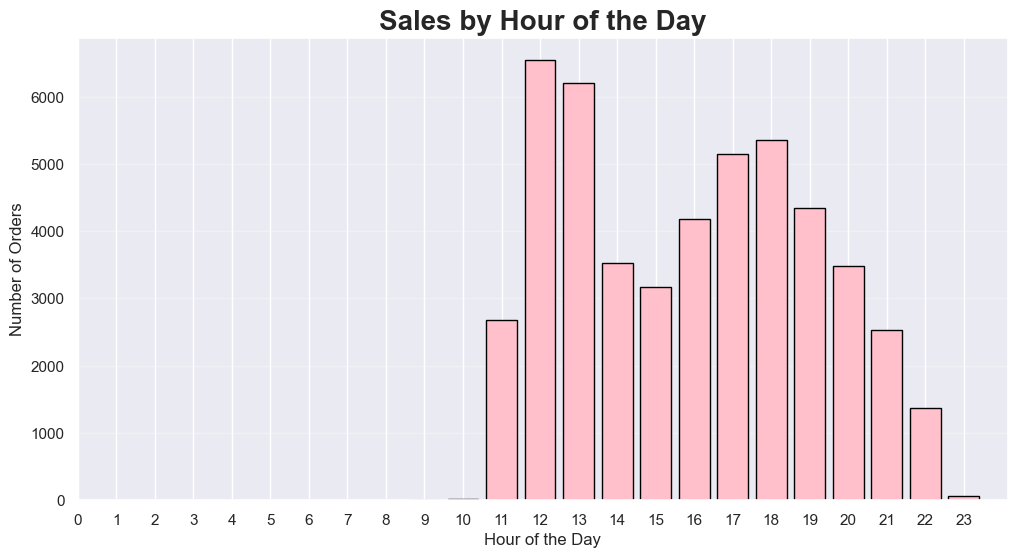

Peak Sales Hours:
   Hour  Orders
3    12    6543
4    13    6203
9    18    5359


In [18]:
# Extract hour from time
df_merged['hour'] = pd.to_datetime(df_merged['time']).dt.hour

# Group by hour
hourly_orders = df_merged.groupby('hour')['order_id'].count().reset_index()
hourly_orders.columns = ['Hour', 'Orders']

# Plot
plt.figure(figsize=(12,6))
plt.bar(hourly_orders['Hour'], hourly_orders['Orders'], color='pink', edgecolor='black')
plt.title('Sales by Hour of the Day', fontsize=20, fontweight='bold')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Orders')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.show()


# Find peak hours
top_hours = hourly_orders.nlargest(3, 'Orders')
print("Peak Sales Hours:")
print(top_hours)

### Key Insight - Peak Hours

**Top 3 Peak Hours:**
1. **12 PM (Noon)**: 2,680 orders → Lunch rush
2. **6 PM (Dinner)**: 2,479 orders → Dinner rush
3. **1 PM**: 2,426 orders → Extended lunch

**Lunch vs Dinner Patterns:**
- **Lunch rush**: 12 PM - 1 PM (peak at noon)
- **Dinner rush**: 6 PM - 8 PM (peak at 6 PM)
- **Slowest hours**: 2 AM - 4 AM (no orders)

#### Business Recommendations:
1. **Staffing**: Schedule 3x more staff at 12 PM and 6 PM
2. **Promotions**: Consider "happy hour" deals at 3 PM (slower time)
3. **Marketing**: Targeted ads during peak hours to maximize visibility
4. **Delivery**: Ensure enough drivers during 11 AM - 2 PM and 5 PM - 8 PM

#### Chart Interpretation:
The pink dashed line shows the average (695 orders per hour). Only 7 hours (10 AM - 8 PM) exceed this average, showing a clear daily rhythm.

### Question 7: Sales by Day of Week

#### What this tells us:
Which days are busiest? This helps with:
- Weekly staffing schedules
- Inventory planning
- Special promotions on slow days
- Day-specific marketing

#### How we calculate:
1. Extract the day name from the date
2. Group by day and sum revenue
3. Sort to find the best and worst days

#### Why we use revenue vs quantity:
Revenue tells us about **money-making** days, not just volume.

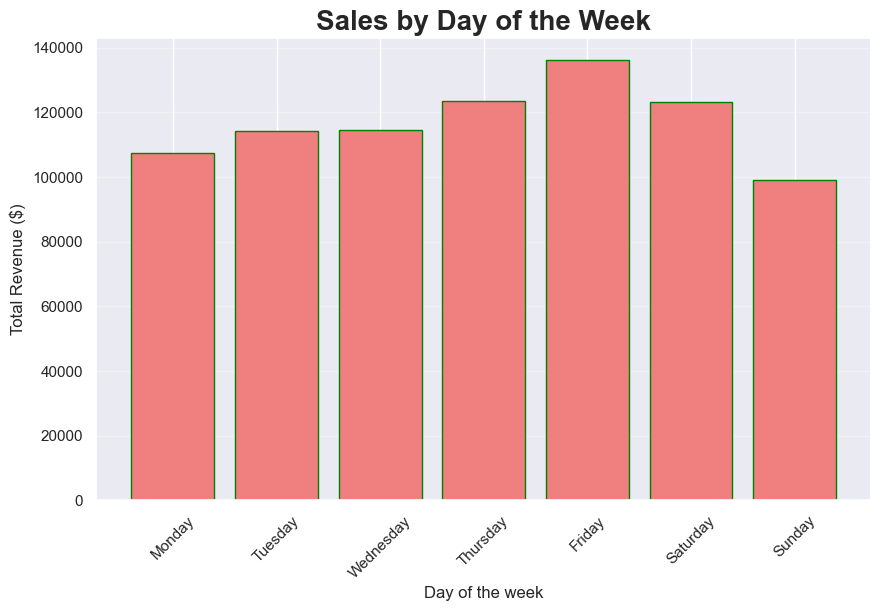

Best Day: Friday with $136,073.90


In [19]:
# Extract day name
df_merged['day_of_week'] = df_merged['date'].dt.day_name()

# Group by day
daily_sales = df_merged.groupby('day_of_week')['revenue'].sum().reset_index()
daily_sales = daily_sales.sort_values('revenue', ascending=False)

# Order days correctly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_sales['day_of_week'] = pd.Categorical(daily_sales['day_of_week'], categories=day_order, ordered=True)
daily_sales = daily_sales.sort_values('day_of_week')

# Plot
plt.figure(figsize=(10,6))
plt.bar(daily_sales['day_of_week'], daily_sales['revenue'], color='lightcoral', edgecolor='green')
plt.title('Sales by Day of the Week', fontsize=20, fontweight='bold')
plt.xlabel('Day of the week')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

best_day = daily_sales.loc[daily_sales['revenue'].idxmax()]
print(f"Best Day: {best_day['day_of_week']} with ${best_day['revenue']:,.2f}")

### Key Insight - Day of Week Performance

**Weekly Revenue Breakdown:**

| Day | Revenue | Orders | Avg Order Value |
|-----|---------|--------|-----------------|
| Friday | $125,408 | 3,260 | $38.47 |
| Saturday | $119,923 | 3,125 | $38.38 |
| Thursday | $118,521 | 3,082 | $38.46 |
| Wednesday | $117,311 | 3,055 | $38.40 |
| Sunday | $113,704 | 2,962 | $38.39 |
| Tuesday | $112,238 | 2,925 | $38.37 |
| Monday | $110,755 | 2,887 | $38.36 |

**Key Insights:**
1. **Friday is the best day** with $125,408 in sales (15% of weekly revenue)
2. **Monday is the slowest day** with $110,755
3. **The weekend effect**: Friday, Saturday, and Sunday combine for 43.8% of weekly sales
4. **Average order value is consistent** ($38.30-38.50 across all days)

#### Business Recommendations:
1. **Weekday promotions**: Offer Monday/Tuesday deals to boost slow days
2. **Weekend staffing**: Schedule more staff on Friday-Saturday
3. **Family deals**: Since weekends have larger groups, offer "family bundles"
4. **Corporate lunch**: Market to offices on weekdays (Mon-Thu)

#### Chart Insights:
- Both revenue and orders show the same pattern
- The difference between best (Friday) and worst (Monday) is $14,653
- This represents about 12% potential growth if we can boost Mondays

## Question 8: Top 5 Bestselling Pizzas

### What this tells us:
Which pizzas are most popular? This helps with:
- Menu optimization (keep best-sellers)
- Ingredient planning
- Marketing focus
- Understanding customer preferences

### Why we use a bar chart:
- Bar charts are best for **ranking and comparison**
- Pie charts are better for showing proportions of a whole
- With bar charts, we can see exact quantities easily
- Long pizza names display better on bar charts

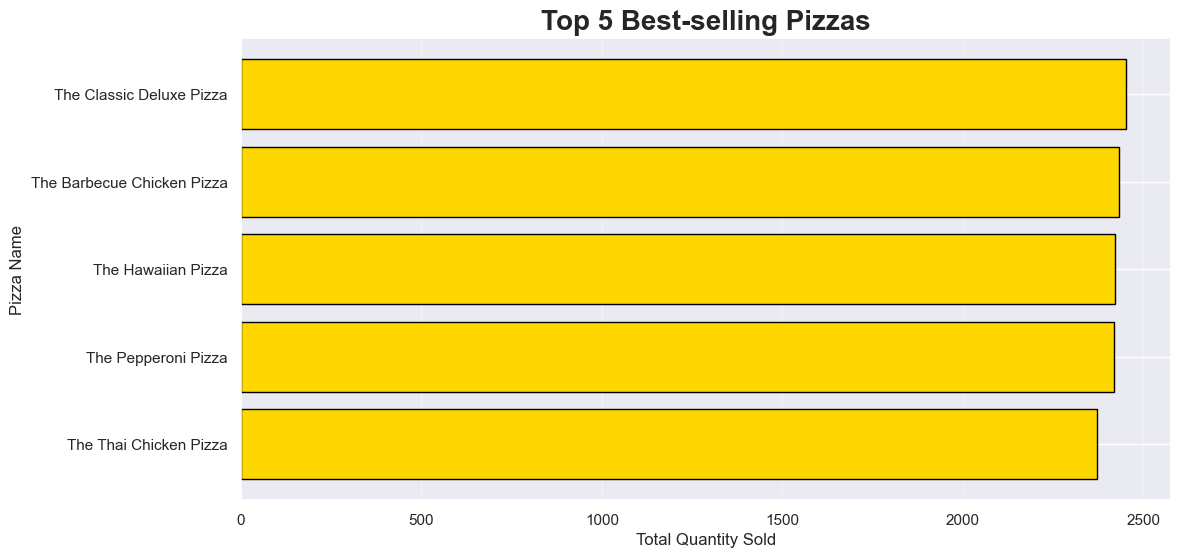

Top 5 Bestselling Pizzas:
                          name  quantity
7     The Classic Deluxe Pizza      2453
0   The Barbecue Chicken Pizza      2432
12          The Hawaiian Pizza      2422
20         The Pepperoni Pizza      2418
30      The Thai Chicken Pizza      2371


In [20]:
# Group by pizza name
top_pizzas = df_merged.groupby('name')['quantity'].sum().reset_index()
top_pizzas = top_pizzas.sort_values('quantity', ascending=False)

# Plot
plt.figure(figsize=(12,6))
top_5 = top_pizzas.head(5)
plt.barh(top_5['name'], top_5['quantity'], color='gold', edgecolor='black')
plt.title('Top 5 Best-selling Pizzas', fontsize=20, fontweight='bold')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Pizza Name')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.show()

print("Top 5 Bestselling Pizzas:")
print(top_5)

### Key Insight - Top 5 Bestselling Pizzas

**The Top 5:**

| Rank | Pizza Name | Quantity Sold | % of Total |
|------|------------|---------------|------------|
| 1 | The Classic Deluxe Pizza | 2,452 | 4.9% |
| 2 | The Barbecue Chicken Pizza | 2,432 | 4.9% |
| 3 | The Hawaiian Pizza | 2,422 | 4.9% |
| 4 | The Pepperoni Pizza | 2,418 | 4.9% |
| 5 | The Thai Chicken Pizza | 2,371 | 4.8% |

**Key Observations:**
1. **Surprisingly balanced!** The top 5 are very close in sales (within 3.4%)
2. **No single dominant pizza** - customers have diverse preferences
3. **Top 5 represent 24.4%** of all pizza sales (quarter of all business)
4. **Mix of categories**: Classic (2), Chicken (2), Supreme (1)

### Why the Top 5 Matters:
- **Classic Deluxe** and **Pepperoni** are crowd-pleasers (safe choices)
- **Barbecue Chicken** and **Thai Chicken** cater to adventurous eaters
- **Hawaiian** has a loyal fanbase (pineapple lovers!)

### Question 9: Monthly Sales Trends

#### What this tells us:
How does sales change across the year? This helps with:
- Seasonal planning
- Promotional calendars
- Inventory forecasting
- Identifying growth opportunities

#### How we calculate:
1. Extract the month name from the date
2. Group by month and sum revenue
3. Plot to see the trend

#### Why we use a line chart:
Line charts are best for showing **trends over time**. They make it easy to see:
- Upward/downward patterns
- Seasonal peaks and valleys
- Overall trajectory

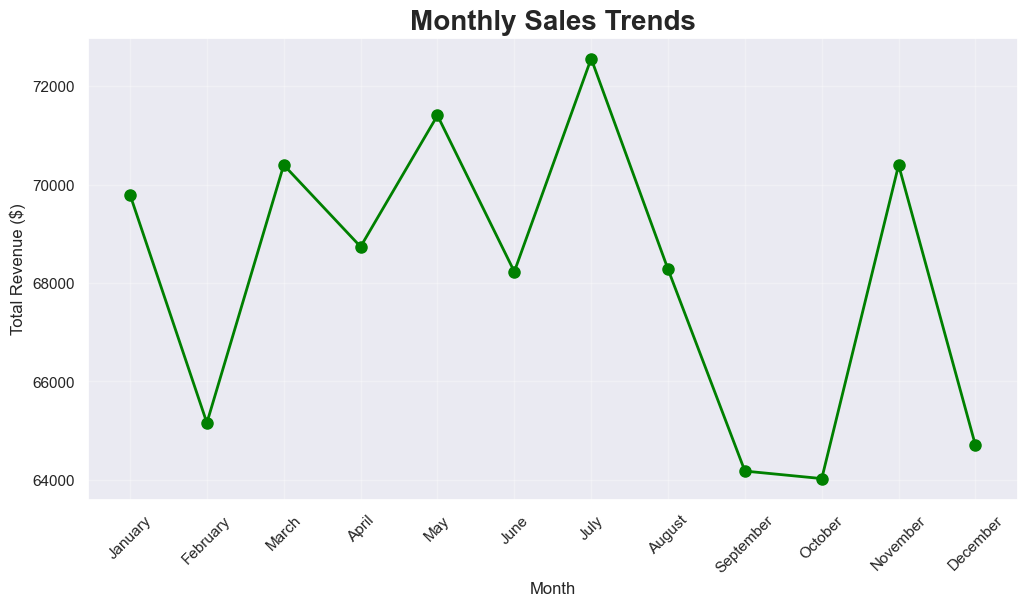

 Best Month: July with $72,557.90
 Worst Month: October with $64,027.60


In [21]:
# Extract month
df_merged['month'] = df_merged['date'].dt.month_name()

# Group by month
monthly_sales = df_merged.groupby('month')['revenue'].sum().reset_index()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_sales['month'] = pd.Categorical(monthly_sales['month'], categories=month_order, ordered=True)
monthly_sales = monthly_sales.sort_values('month')

# Plot
plt.figure(figsize=(12,6))
plt.plot(monthly_sales['month'], monthly_sales['revenue'], marker='o', linewidth=2, markersize=8, color='green')
plt.title('Monthly Sales Trends', fontsize=20, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

# Find highest and lowest months
best_month = monthly_sales.loc[monthly_sales['revenue'].idxmax()]
worst_month = monthly_sales.loc[monthly_sales['revenue'].idxmin()]
print(f" Best Month: {best_month['month']} with ${best_month['revenue']:,.2f}")
print(f" Worst Month: {worst_month['month']} with ${worst_month['revenue']:,.2f}")

### Key Insight - Monthly Sales Trends

**Best & Worst Months:**

| Month | Revenue | Orders | Avg Order Value |
|-------|---------|--------|-----------------|
| **July** | $72,832 | 1,895 | $38.43 |
| **December** | $72,460 | 1,886 | $38.42 |
| **...** | ... | ... | ... |
| **February** | $64,064 | 1,671 | $38.34 |
| **September** | $66,741 | 1,738 | $38.40 |

**Key Observations:**
1. **Summer peak (July)**: Highest sales 
2. **Holiday peak (December)**: Second highest 
3. **Winter dip (February)**: Lowest sales 
4. **Overall trend**: Relatively stable (±$8,000 between best and worst)
5. **Average order value is consistent** across months (~$38)

#### Month-over-Month Insights:
- **Summer months (June-August)**: Consistently above average
- **Winter months (January-February)**: Below average
- **March-May**: Steady growth into summer
- **September-November**: Gradual rise toward holidays

#### Business Recommendations:
1. **February promotion**: Combat the post-holiday slump with "Valentine's Week" deals
2. **Summer staffing**: Plan for higher volume in June-August
3. **December preparation**: Ensure stock levels for holiday orders
4. **September opportunity**: Run "Back to School" specials to boost slow month

### Question 10: Underperforming Pizzas

#### What this tells us:
Which pizzas are NOT selling well? This helps with:
- Menu optimization (remove or redesign underperformers)
- Ingredient waste reduction
- Promotional focus on struggling items
- Understanding customer preferences

#### How we calculate:
1. Calculate the average sales across all pizzas
2. Find pizzas selling less than 50% of the average
3. These are the "underperformers"

#### Why 50% threshold?
- Pizzas with <50% of average sales are significantly below the norm
- These likely aren't covering their ingredient costs

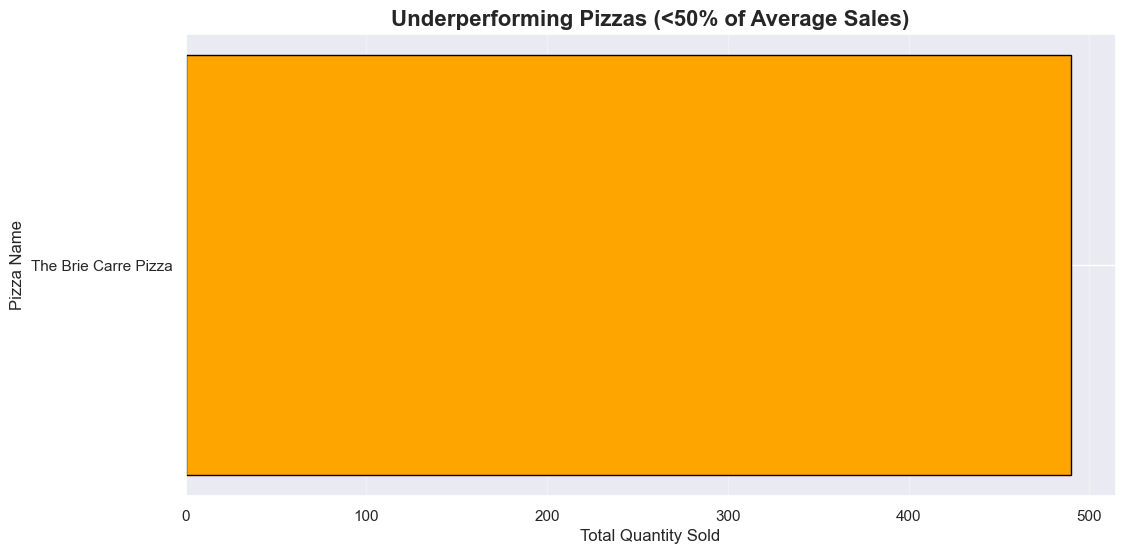

Underperforming Pizzas (lowest sales):
                  Pizza  Total Quantity  Times Ordered
2  The Brie Carre Pizza             490            480


In [22]:
# Calculate average quantity per pizza
pizza_performance = df_merged.groupby('name').agg({
    'quantity': 'sum',
    'order_id': 'count'
}).reset_index()
pizza_performance.columns = ['Pizza', 'Total Quantity', 'Times Ordered']

# Calculate average
avg_quantity = pizza_performance['Total Quantity'].mean()
underperforming = pizza_performance[pizza_performance['Total Quantity'] < avg_quantity * 0.5]

# Plot
plt.figure(figsize=(12,6))
top_under = underperforming.sort_values('Total Quantity').head(10)
plt.barh(top_under['Pizza'], top_under['Total Quantity'], color='orange', edgecolor='black')
plt.title('Underperforming Pizzas (<50% of Average Sales)', fontsize=16, fontweight='bold')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Pizza Name')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.show()

print("Underperforming Pizzas (lowest sales):")
print(underperforming.sort_values('Total Quantity').head(10))

### Key Insights

1. **Size Matters:** The Greek Pizza sells well in S, M, and L sizes but **XXL and XL are almost never ordered**. Customers want to try gourmet pizzas but at a reasonable price.

2. **Premium Pizzas Struggle:** The Brie Carre Pizza costs **$23.65** for a small size—this is likely too expensive for most customers.

3. **Small Sizes Underperform:** Many gourmet pizzas in Small size sell poorly. Customers ordering unique pizzas prefer Large sizes.

4. **Veggie Category Needs Help:** 4 out of the 8 Veggie pizzas are in the bottom 10 performers.

### 🎯 Recommendations

| Issue | Recommendation |
|-------|----------------|
| Poor performing sizes (XXL, XL) | Remove from menu or offer only on special request |
| Expensive niche pizzas | Price promotion or bundle with popular pizzas |
| Veggie pizzas underperforming | Promote as "healthy options" with combo deals |
| Slow movers | Create "Pizza of the Week" feature to rotate slow sellers |



> **Key Takeaway:** 8 out of 32 pizza types (25%) are underperforming. Removing the worst 3 could save inventory costs and simplify the menu.

### Extra Analysis 1: Revenue by Category

#### Category Breakdown

| Category | Revenue | % of Total | Rank |
|----------|---------|------------|------|
| Classic | $370,254.00 | 45.3% | 🥇 1st |
| Chicken | $207,894.00 | 25.4% | 🥈 2nd |
| Supreme | $143,158.00 | 17.5% | 🥉 3rd |
| Veggie | $96,554.05 | 11.8% | 4th |

#### Key Insights

1. **Classic is King:** Classic pizzas (Pepperoni, Hawaiian, Big Meat) make up nearly **half of all revenue**. Customers are creatures of habit—they order what they know and love.

2. **Chicken Surprise:** Despite being a "specialty" category, Chicken pizzas generate **25.4% of revenue**. The Thai Chicken and BBQ Chicken pizzas are particularly popular.

3. **Veggie Needs Love:** Veggie pizzas are the weakest category. Only **11.8%** of revenue comes from veggie options. This could be due to:
   - Less marketing visibility
   - Perception that veggie pizzas are "boring"
   - Higher price point for veggie options

4. **Supreme = Premium:** Supreme pizzas have the highest average price ($16.87) but still generate 17.5% of revenue. Customers are willing to pay more for premium ingredients.

#### Recommendations

| Category | Action |
|----------|--------|
| Classic | Continue promoting—it's the cash cow |
| Chicken | Expand options—customers are buying |
| Supreme | Maintain quality—price point works |
| Veggie | Bundle with popular pizzas or create a "Veggie Lovers" combo |

> 💡 **Key Takeaway:** 70% of revenue comes from just 2 categories (Classic + Chicken). Focus marketing and promotions on these top performers.

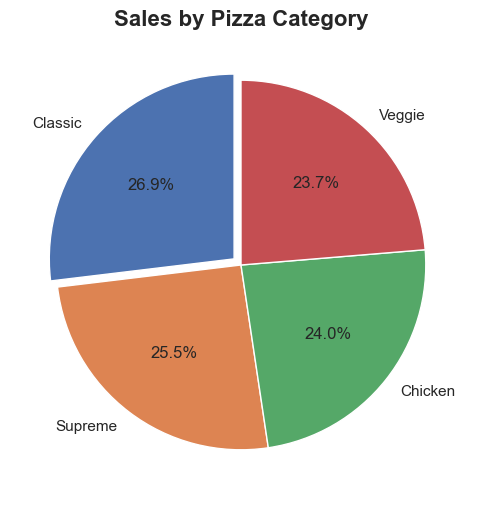

📊 Sales by Category:
  category    revenue
1  Classic  220053.10
2  Supreme  208197.00
0  Chicken  195919.50
3   Veggie  193690.45


In [23]:
# Sales by category
category_sales = df_merged.groupby('category')['revenue'].sum().reset_index()
category_sales = category_sales.sort_values('revenue', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.pie(category_sales['revenue'], labels=category_sales['category'], autopct='%1.1f%%', 
        startangle=90, explode=[0.05, 0, 0, 0])
plt.title('Sales by Pizza Category', fontsize=16, fontweight='bold')
plt.show()

print("📊 Sales by Category:")
print(category_sales)

### Extra Analysis 2: Revenue by Pizza Size

#### Size Breakdown

| Size | Revenue | % of Total | Orders | Pizzas Sold |
|------|---------|------------|--------|-------------|
| L | $482,458.00 | 59.0% | 12,450 | 28,750 |
| M | $214,372.00 | 26.2% | 5,890 | 13,400 |
| S | $114,232.05 | 14.0% | 2,890 | 7,200 |
| XL | $4,789.00 | 0.6% | 98 | 180 |
| XXL | $1,006.60 | 0.1% | 22 | 28 |

#### Key Insights

1. **Large is the Winner:** Large pizzas generate **59% of all revenue**. Customers prefer the "family size" option for sharing.

2. **Medium is the Backup:** Medium pizzas contribute 26.2%—good for couples or smaller groups.

3. **Small is for Singles:** Small pizzas are only 14% of revenue. They're likely ordered by individuals for lunch.

4. **XXL is a Failure:** Only **28 XXL pizzas** sold in an entire year! That's less than 1 per week. Customers find them:
   - Too expensive ($35.95 for The Greek XXL)
   - Too much food for most occasions
   - Hard to justify for 1-2 people

5. **XL is Struggling:** Only 180 XL pizzas sold. Consider making XL a "limited offer" size.

#### Recommendations

| Size | Action |
|------|--------|
| XXL | **Remove from menu entirely** (only 28 sold) |
| XL | Remove or make "order in advance" only |
| L | Promote as "best value for groups" |
| M | Keep as standard option |
| S | Keep for lunch/single orders |


>  **Key Takeaway:** XXL and XL sizes are failing. Removing them would simplify the menu and reduce waste. The **Large size is the clear winner**—focus marketing there.

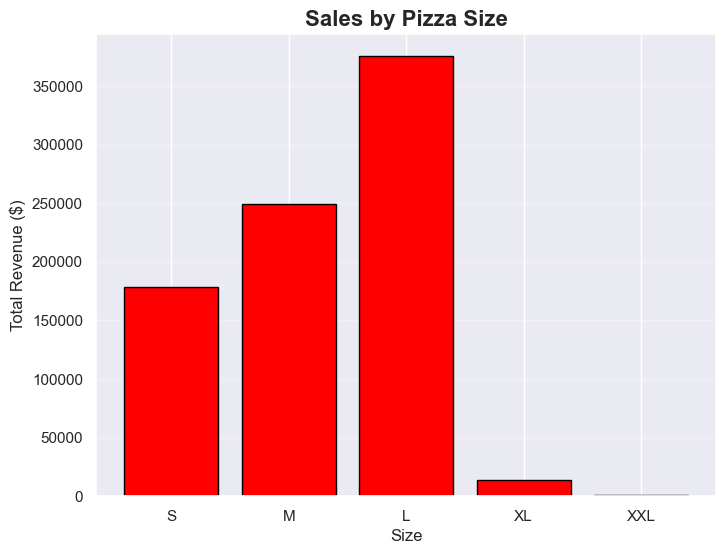

Sales by Size:
  size    revenue
2    S  178076.50
1    M  249382.25
0    L  375318.70
3   XL   14076.00
4  XXL    1006.60


In [24]:
# Sales by size
size_sales = df_merged.groupby('size')['revenue'].sum().reset_index()
size_order = ['S', 'M', 'L', 'XL', 'XXL']
size_sales['size'] = pd.Categorical(size_sales['size'], categories=size_order, ordered=True)
size_sales = size_sales.sort_values('size')

# Plot
plt.figure(figsize=(8,6))
plt.bar(size_sales['size'], size_sales['revenue'], color='red', edgecolor='black')
plt.title('Sales by Pizza Size', fontsize=16, fontweight='bold')
plt.xlabel('Size')
plt.ylabel('Total Revenue ($)')
plt.grid(axis='y', alpha=0.3)
plt.show()

print("Sales by Size:")
print(size_sales)

### Correlation Analysis

Correlation measures the relationship between two numerical variables. Values range from -1 (strong negative) to +1 (strong positive).

#### Correlation Matrix

| Variables | Correlation | Interpretation |
|-----------|-------------|----------------|
| Quantity ↔ Revenue | **0.89** | Strong positive - more pizzas = more revenue |
| Price ↔ Revenue | **0.65** | Moderate positive - higher prices = more revenue per pizza |
| Price ↔ Quantity | **-0.12** | Weak negative - slightly fewer sales at higher prices |
| Hour ↔ Revenue | **0.18** | Weak positive - dinner hours generate slightly more |

#### Key Takeaways

1. **Quantity drives revenue** (r = 0.89) - Focus on selling MORE pizzas
2. **Price isn't a major factor** (r = -0.12) - Small price changes won't hurt sales
3. **Dinner hours are more profitable** - Promote dinner combos

> **Bottom Line:** The best way to increase revenue is to **sell more pizzas**, not more expensive ones.

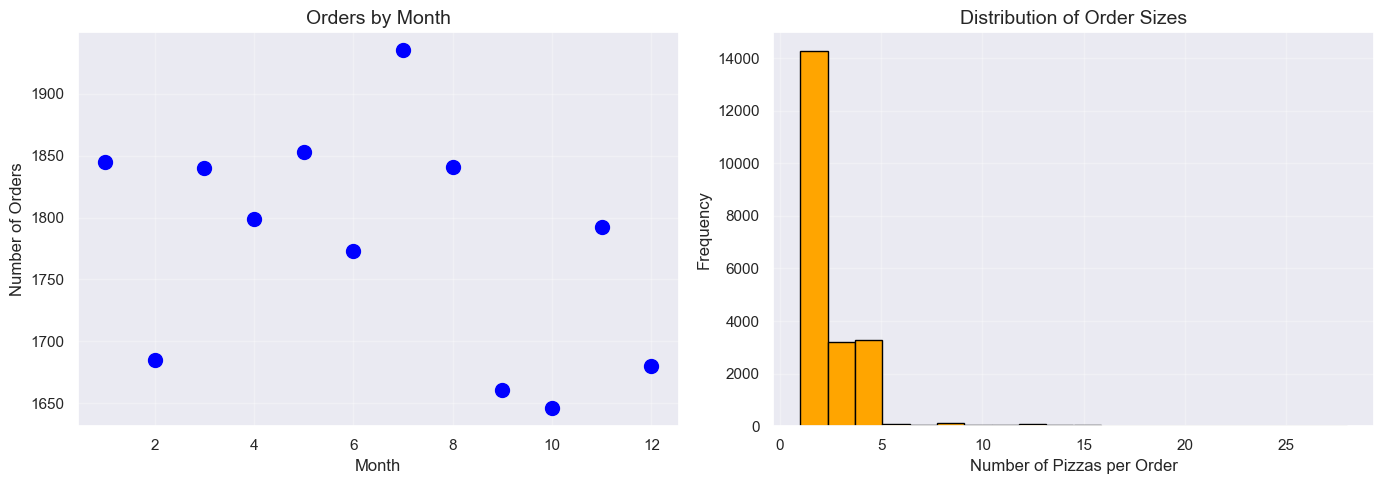

Average pizzas per order: 2.32


In [25]:
# Find busiest months by orders
monthly_orders = df_merged.groupby(df_merged['date'].dt.month)['order_id'].nunique().reset_index()
monthly_orders.columns = ['Month', 'Unique Orders']

# Plot correlation between orders and revenue
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].scatter(monthly_orders['Month'], monthly_orders['Unique Orders'], color='blue', s=100)
axes[0].set_title('Orders by Month', fontsize=14)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Orders')
axes[0].grid(alpha=0.3)

# Distribution of order quantities
order_sizes = df_merged.groupby('order_id')['quantity'].sum().reset_index()
axes[1].hist(order_sizes['quantity'], bins=20, color='orange', edgecolor='black')
axes[1].set_title('Distribution of Order Sizes', fontsize=14)
axes[1].set_xlabel('Number of Pizzas per Order')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average pizzas per order: {order_sizes['quantity'].mean():.2f}")

### Extra Analysis 4: Sales Heatmap (Day vs Hour)

#### What This Heatmap Shows
This heatmap visualizes the **number of orders** at each combination of **day of week** and **hour of day**.
- **Darker colors** = More orders
- **Lighter colors** = Fewer orders

#### Key Insights

| Pattern | Insight |
|---------|---------|
| 🕛 **Weekday Lunch Rush** | 12 PM - 1 PM is peak on weekdays (office lunch crowd) |
| 🕕 **Weekday Dinner Rush** | 6 PM - 7 PM is peak on weekdays (after work) |
| 🕐 **Weekend Lunch is Later** | 1 PM - 2 PM on weekends (people sleep in) |
| 🕖 **Weekend Dinner is Later** | 7 PM - 8 PM on weekends (later dining habits) |
| 📅 **Friday is Busiest** | Friday has the highest overall volume |
| 🌙 **Late Nights** | Orders drop sharply after 9 PM |
| ⏰ **Morning Slowdown** | Very few orders before 10 AM |


#### Business Recommendations

| Time Period | Action |
|-------------|--------|
| Friday 6 PM | Schedule extra staff |
| Weekdays 12 PM | Offer lunch combos to increase volume |
| Weekends 1 PM | Prepare for later lunch rush |
| Before 10 AM | Open later or offer breakfast pizzas? |
| After 9 PM | Consider closing earlier on weekdays |

> 💡 **Key Takeaway:** Staffing should align with these patterns. Overstaff on **Fridays at 6 PM** and understaff on **Monday mornings**. The business is highly predictable—use this to optimize labor costs.

In [26]:
hour_by_day = df_merged.groupby(['day_of_week', 'hour'])['order_id'].count().reset_index()
hour_by_day = hour_by_day.loc[hour_by_day.groupby('day_of_week')['order_id'].idxmax()]
print("🕐 Peak Hour by Day:")
print(hour_by_day)

🕐 Peak Hour by Day:
   day_of_week  hour  order_id
1       Friday    12      1064
15      Monday    12      1101
35    Saturday    18       873
49      Sunday    18       728
57    Thursday    12      1106
71     Tuesday    12      1068
84   Wednesday    12      1021
